```

Estrutura do EDA

1.  Imports e configurações
2.  Carregamento dos dados
3.  Shape e tipos de dados
4.  Primeiras linhas (head)
5.  Últimas linhas (tail)
6.  Estatísticas descritivas
7.  Análise de nulos
8.  Análise de duplicatas
9.  Distribuição das variáveis numéricas
10. Análise temporal (quando as compras acontecem)
11. Análise geográfica (de onde vêm os clientes)
12. Análise de produtos (o que mais vende)
13. Análise de clientes (comportamento)
14. Identificação de outliers
15. Sumário final — lista de problemas encontrados para o ETL

### Célula 1 — Imports e configurações

In [1]:
# Bibliotecas essenciais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
pd.set_option('display.max_columns', None)       # mostrar todas as colunas
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 casas decimais

sns.set_theme(style='whitegrid')                 # estilo dos gráficos
plt.rcParams['figure.figsize'] = (12, 5)         # tamanho padrão dos gráficos

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


### Célula 2 — Carregamento dos dados

In [4]:
# O dataset UCI Online Retail II tem 2 abas: Year 2009-2010 e Year 2010-2011
# Vamos carregar as duas e unir em um único DataFrame

df_0910 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_1011 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2010-2011')

df = pd.concat([df_0910, df_1011], ignore_index=True)

print("Dataset carregado com sucesso!")
print(f"Ano 2009-2010: {df_0910.shape[0]:,} linhas")
print(f"Ano 2010-2011: {df_1011.shape[0]:,} linhas")
print(f"Total unificado: {df.shape[0]:,} linhas")

Dataset carregado com sucesso!
Ano 2009-2010: 525,461 linhas
Ano 2010-2011: 541,910 linhas
Total unificado: 1,067,371 linhas


### Célula 3 — Shape e tipos de dados

In [5]:
print(f"Dimensões do dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas")
print(f"\n{'='*45}")
print("Tipos de cada coluna:")
print('='*45)
print(df.dtypes)

Dimensões do dataset: 1,067,371 linhas x 8 colunas

Tipos de cada coluna:
Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID           float64
Country                   str
dtype: object


### Célula 4 — Primeiras linhas

In [6]:
print("Primeiras 5 linhas do dataset:")
print('='*45)
df.head()

Primeiras 5 linhas do dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.00,United Kingdom


### Célula 5 — Últimas linhas

In [7]:
print("Últimas 5 linhas do dataset:")
print('='*45)
df.tail()

Últimas 5 linhas do dataset:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.00,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.00,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.00,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.00,France
1067370,581587,POST,POSTAGE,1,2011-12-09 12:50:00,18.00,12680.00,France


### Célula 6 — Estatísticas descritivas

In [8]:
print("Estatísticas descritivas das colunas numéricas:")
print('='*45)
df.describe()

Estatísticas descritivas das colunas numéricas:


,Quantity,InvoiceDate,Price,Customer ID
count,1067371.00,1067371,1067371.00,824364.00
mean,9.94,2011-01-02 21:13:55.394029,4.65,15324.64
min,-80995.00,2009-12-01 07:45:00,-53594.36,12346.00
25%,1.00,2010-07-09 09:46:00,1.25,13975.00
50%,3.00,2010-12-07 15:28:00,2.10,15255.00
75%,10.00,2011-07-22 10:23:00,4.15,16797.00
max,80995.00,2011-12-09 12:50:00,38970.00,18287.00
std,172.71,NaN,123.55,1697.46


### Célula 7 — Análise de nulos

In [10]:
print("Análise de valores nulos:")
print('='*45)

nulos = df.isnull().sum()
percentual = (nulos / len(df) * 100).round(2)

resumo_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Percentual (%)': percentual
})

print(resumo_nulos[resumo_nulos['Nulos'] > 0])

Análise de valores nulos:
              Nulos  Percentual (%)
Description    4382            0.41
Customer ID  243007           22.77


### Célula 8 — Análise de duplicatas

In [14]:
print("Análise de duplicatas:")
print('='*45)

duplicatas = df.duplicated().sum()
percentual_dup = (duplicatas / len(df) * 100).round(2)

print(f"Total de linhas duplicadas: {duplicatas:,}")
print(f"Percentual do dataset: {percentual_dup}%")
print(f"\nExemplo de linhas duplicadas:")
df[df.duplicated(keep=False)].head(10)

Análise de duplicatas:
Total de linhas duplicadas: 34,335
Percentual do dataset: 3.22%

Exemplo de linhas duplicadas:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.00,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.00,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.00,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.00,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.00,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.00,United Kingdom


```
Registro parcial da EDA - (Nulos, Duplicados, Análise Descritiva)

🚨 Crítico
   → 22,77% sem Customer ID (243.007 linhas)
   → Quantity negativa (mín: -80.995) — devoluções
   → Price negativo (mín: -53.594,36) — estornos
   → Duplicatas verdadeiras (34.335 linhas / 3,22%)

⚠️ Atenção
   → Invoice com tipos misturados (números + string com 'C')
   → StockCode com códigos não-produto (ex: POST)
   → Customer ID como float em vez de inteiro
   → Outliers em Quantity e Price (média >> mediana)

✅ Ok
   → Description nulos (0,41%) — pequeno, fácil de tratar
   → InvoiceDate já em datetime — sem trabalho no ETL
   → Arquivo carregou limpo, sem corrupção

### Célula 9 — Estatísticas descritivas das colunas de texto

In [16]:
print("Estatísticas das colunas categóricas:")
print('='*45)
df.describe(include='object')

Estatísticas das colunas categóricas:


C:\Users\Usuario\AppData\Local\Temp\ipykernel_18916\2701514693.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Invoice,StockCode,Description,Country
count,1067371,1067371,1062989,1067371
unique,53628,5305,5698,43
top,537434,85123A,WHITE HANGING HEART T-LIGHT HOLDER,United Kingdom
freq,1350,5829,5918,981330


### Célula 10 — Investigando o Invoice com 'C'

In [18]:
print("Investigando invoices de devolução:")
print('='*45)

cancelamentos = df[df['Invoice'].astype(str).str.startswith('C')]

print(f"Total de registros com Invoice iniciando em 'C': {len(cancelamentos):,}")
print(f"Percentual do dataset: {round(len(cancelamentos)/len(df)*100, 2)}%")
print(f"\nExemplo:")
cancelamentos.head()

Investigando invoices de devolução:
Total de registros com Invoice iniciando em 'C': 19,494
Percentual do dataset: 1.83%

Exemplo:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.00,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.00,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.00,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.00,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.00,Australia


```
Registro parcial da EDA - (Nulos, Duplicados, Análise Categórica)

🚨 Crítico
   → 22,77% sem Customer ID (243.007 linhas)
   → Duplicatas verdadeiras (34.335 linhas / 3,22%)
   → Cancelamentos com Invoice 'C' (19.494 linhas / 1,83%)
   → Quantity negativa confirmada nas devoluções
   → Price negativo ainda a investigar separadamente

⚠️ Atenção
   → StockCode com códigos não-produto (ex: POST)
   → Customer ID como float em vez de inteiro
   → 91,9% das transações são do Reino Unido
   → Mesma descrição para StockCodes diferentes
   → Country como str nativo, não object

✅ Ok
   → Description nulos (0,41%) — pequeno, fácil tratar
   → InvoiceDate já em datetime
   → Arquivo carregou limpo
   → Cancelamentos bem sinalizados e isoláveis

### Célula 11 — Investigando StockCodes não-produto

In [19]:
print("Investigando StockCodes suspeitos:")
print('='*45)

# Códigos que sabidamente não são produtos
suspeitos = df[~df['StockCode'].astype(str).str.match(r'^\d{5}')]

print(f"Total de registros com StockCode fora do padrão numérico: {len(suspeitos):,}")
print(f"\nStockCodes únicos fora do padrão:")
print(suspeitos['StockCode'].value_counts().head(20))

Investigando StockCodes suspeitos:
Total de registros com StockCode fora do padrão numérico: 6,093

StockCodes únicos fora do padrão:
StockCode
POST            2122
DOT             1446
M               1421
C2               282
D                177
S                104
BANK CHARGES     102
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_20      29
gift_0001_30      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
gift_0001_10      16
CRUK              16
DCGS0076          15
TEST001           15
DCGS0003          14
Name: count, dtype: int64


### Célula 12 — Investigando Price negativo e zero

In [20]:
print("Investigando preços anômalos:")
print('='*45)

price_zero = df[df['Price'] == 0]
price_negativo = df[df['Price'] < 0]

print(f"Registros com Price = 0: {len(price_zero):,}")
print(f"Registros com Price < 0: {len(price_negativo):,}")
print(f"\nExemplo de Price negativo:")
price_negativo[['Invoice','StockCode','Description','Quantity','Price']].head()

Investigando preços anômalos:
Registros com Price = 0: 6,202
Registros com Price < 0: 5

Exemplo de Price negativo:


,Invoice,StockCode,Description,Quantity,Price
179403,A506401,B,Adjust bad debt,1,-53594.36
276274,A516228,B,Adjust bad debt,1,-44031.79
403472,A528059,B,Adjust bad debt,1,-38925.87
825444,A563186,B,Adjust bad debt,1,-11062.06
825445,A563187,B,Adjust bad debt,1,-11062.06


### Célula 13 — Investigando Price zero

In [21]:
print("Investigando registros com Price zero:")
print('='*45)

price_zero = df[df['Price'] == 0]

print(f"StockCodes mais frequentes com Price zero:")
print(price_zero['StockCode'].value_counts().head(10))
print(f"\nDescriptions mais frequentes com Price zero:")
print(price_zero['Description'].value_counts().head(10))

Investigando registros com Price zero:
StockCodes mais frequentes com Price zero:
StockCode
46000M    18
22501     18
79321     17
21116     16
22423     16
23084     16
46000S    15
22734     15
22139     14
35965     14
Name: count, dtype: int64

Descriptions mais frequentes com Price zero:
Description
check                    162
?                         92
damages                   84
damaged                   81
found                     28
missing                   27
sold as set on dotcom     20
Damaged                   17
adjustment                16
OWL DOORSTOP              15
Name: count, dtype: int64


```
Registro final do EDA

🚨 Crítico
   → 22,77% sem Customer ID (243.007 linhas)
   → Duplicatas verdadeiras (34.335 linhas / 3,22%)
   → Cancelamentos Invoice 'C' (19.494 linhas / 1,83%)
   → Invoice 'A' — ajustes contábeis (5 linhas)
   → StockCode não-produto (6.093 linhas)
   → Price zero — movimentações internas (6.202 linhas)
   → Price negativo — bad debt (5 linhas)

⚠️ Atenção
   → Customer ID como float em vez de inteiro
   → 91,9% das transações são do Reino Unido
   → Mesma descrição para StockCodes diferentes
   → Country como str nativo, não object

✅ Ok
   → Description nulos (0,41%)
   → InvoiceDate já em datetime
   → Arquivo carregou limpo
   → Cancelamentos bem sinalizados e isoláveis
   → Price negativo concentrado em apenas 5 linhas

### Célula 14 — Análise temporal

In [22]:
print("Análise temporal das transações:")
print('='*45)

df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

transacoes_mes = df.groupby(['Year','Month'])['Invoice'].nunique().reset_index()
transacoes_mes.columns = ['Year','Month','Num_Pedidos']

print(transacoes_mes.to_string(index=False))

Análise temporal das transações:
 Year  Month  Num_Pedidos
 2009     12         2330
 2010      1         1633
 2010      2         1969
 2010      3         2367
 2010      4         1892
 2010      5         2418
 2010      6         2216
 2010      7         2017
 2010      8         1877
 2010      9         2375
 2010     10         2965
 2010     11         3669
 2010     12         2025
 2011      1         1476
 2011      2         1393
 2011      3         1983
 2011      4         1744
 2011      5         2162
 2011      6         2012
 2011      7         1927
 2011      8         1737
 2011      9         2327
 2011     10         2637
 2011     11         3462
 2011     12         1015


### Célula 15 — Visualizando a sazonalidade

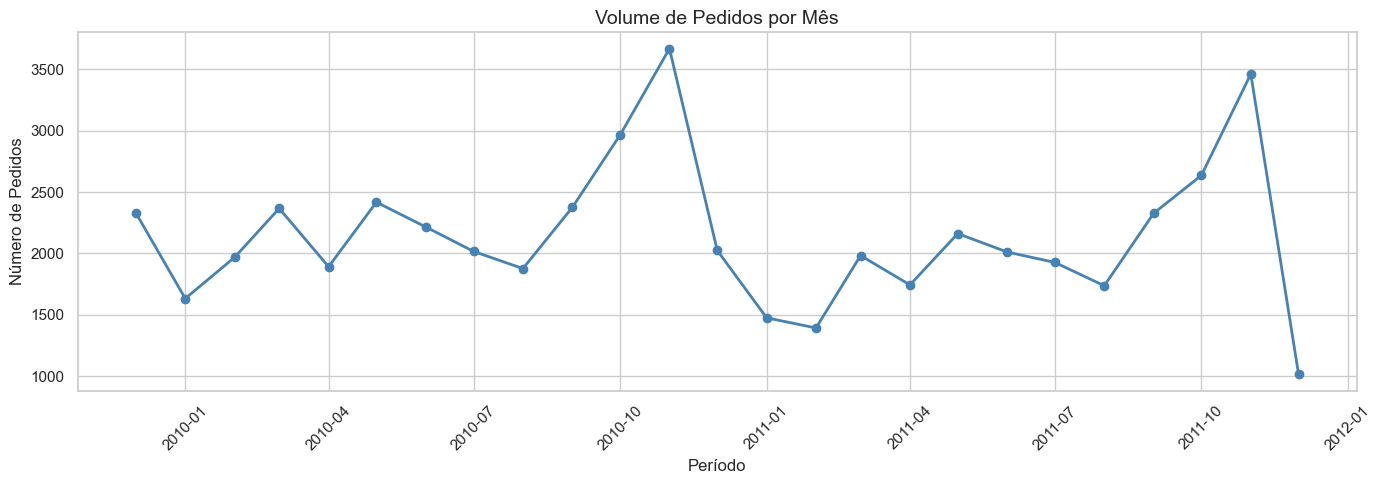

In [23]:
transacoes_mes['Periodo'] = pd.to_datetime(
    transacoes_mes['Year'].astype(str) + '-' + 
    transacoes_mes['Month'].astype(str), format='%Y-%m'
)

plt.figure(figsize=(14, 5))
plt.plot(transacoes_mes['Periodo'], transacoes_mes['Num_Pedidos'], 
         marker='o', linewidth=2, color='steelblue')

plt.title('Volume de Pedidos por Mês', fontsize=14)
plt.xlabel('Período')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

````
3 insights de negócio diretos:

📈 Oportunidade   → Setembro a Novembro é o período crítico
                    Estratégias de retenção devem ser ativadas em Agosto

📉 Risco          → Janeiro e Fevereiro são os meses de maior churn
                    Clientes somem após o Natal — momento de campanhas de reativação

🎯 Segmentação    → Clientes que compram fora do pico (Jan-Ago)
                    são potencialmente mais fiéis e valiosos

### Célula 16 — Análise por dia da semana e hora

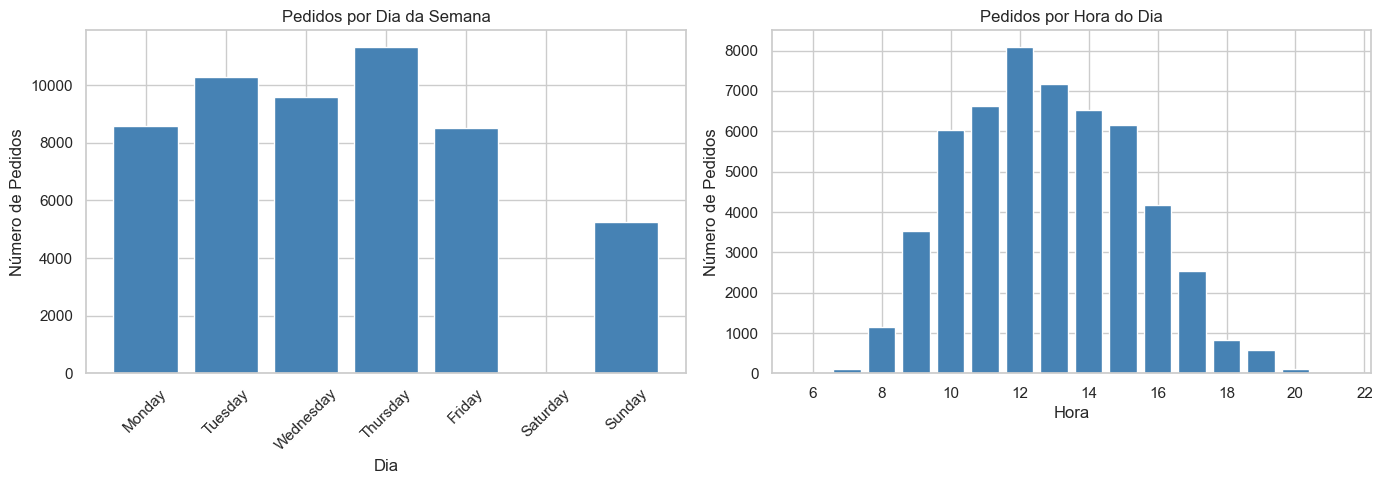

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pedidos por dia da semana
ordem_dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
pedidos_dia = df.groupby('DayOfWeek')['Invoice'].nunique().reindex(ordem_dias)

axes[0].bar(pedidos_dia.index, pedidos_dia.values, color='steelblue')
axes[0].set_title('Pedidos por Dia da Semana')
axes[0].set_xlabel('Dia')
axes[0].set_ylabel('Número de Pedidos')
axes[0].tick_params(axis='x', rotation=45)

# Pedidos por hora
pedidos_hora = df.groupby('Hour')['Invoice'].nunique()

axes[1].bar(pedidos_hora.index, pedidos_hora.values, color='steelblue')
axes[1].set_title('Pedidos por Hora do Dia')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('Número de Pedidos')

plt.tight_layout()
plt.show()

```
Insight estratégico combinado

Perfil do comprador ideal desse e-commerce:

→ É um comprador corporativo (B2B)
→ Compra durante horário comercial
→ Fecha pedidos às Quintas antes do almoço
→ Some em Janeiro/Fevereiro
→ Volta forte em Setembro/Outubro

Estratégia de retenção ideal:
→ Contato na Quinta entre 10h e 12h
→ Campanhas de reativação em Janeiro
→ Ofertas antecipadas em Agosto

### Célula 17 — Análise geográfica

In [25]:
print("Análise geográfica — Top 15 países:")
print('='*45)

paises = df.groupby('Country').agg(
    Pedidos=('Invoice', 'nunique'),
    Clientes=('Customer ID', 'nunique'),
    Receita=('Price', 'sum')
).sort_values('Pedidos', ascending=False).head(15)

paises['Receita'] = paises['Receita'].apply(lambda x: f"£{x:,.2f}")
print(paises.to_string())

Análise geográfica — Top 15 países:
                 Pedidos  Clientes        Receita
Country                                          
United Kingdom     49108      5410  £4,453,169.29
Germany             1095       107     £67,564.45
EIRE                 806         5    £125,305.45
France               746        95     £67,231.31
Netherlands          250        23     £15,663.23
Spain                188        41     £20,539.47
Belgium              183        29     £14,766.88
Sweden               129        19      £8,709.92
Portugal             124        24     £17,125.84
Switzerland          123        22     £12,049.88
Australia            117        15      £8,111.07
Italy                 92        17      £8,479.46
Channel Islands       79        14      £9,056.80
Finland               68        15      £5,234.61
Japan                 56        10      £1,258.61


```
Insight estratégico

3 perfis geográficos distintos emergem:

→ Reino Unido   = mercado principal, alta frequência
→ EIRE          = poucos clientes, altíssimo valor — VIP B2B
→ Europa        = mercado secundário, comportamento similar entre si

### Célula 18 — Análise de produtos — Top 20 mais vendidos

In [26]:
print("Top 20 produtos mais vendidos por quantidade:")
print('='*45)

# Filtrar só compras reais antes de analisar produtos
produtos = df[
    (df['Quantity'] > 0) & 
    (df['Price'] > 0) & 
    (~df['Invoice'].astype(str).str.startswith('C'))
]

top_produtos = produtos.groupby('Description').agg(
    Quantidade_Total=('Quantity', 'sum'),
    Num_Pedidos=('Invoice', 'nunique'),
    Receita_Total=('Price', 'sum')
).sort_values('Quantidade_Total', ascending=False).head(20)

print(top_produtos.to_string())

Top 20 produtos mais vendidos por quantidade:
                                     Quantidade_Total  Num_Pedidos  Receita_Total
Description                                                                      
WORLD WAR 2 GLIDERS ASSTD DESIGNS              110138         1019         295.65
WHITE HANGING HEART T-LIGHT HOLDER              96683         5455       18113.35
ASSORTED COLOUR BIRD ORNAMENT                   81809         2807        5452.15
PAPER CRAFT , LITTLE BIRDIE                     80995            1           2.08
JUMBO BAG RED RETROSPOT                         79279         3269        8090.66
MEDIUM CERAMIC TOP STORAGE JAR                  78033          247         367.12
BROCADE RING PURSE                              71430          456         144.15
PACK OF 60 PINK PAISLEY CAKE CASES              56794         1993        1481.14
60 TEATIME FAIRY CAKE CASES                     54716         2127        1498.72
SMALL POPCORN HOLDER                            4994

### Célula 19 — Análise de clientes — distribuição de valor

In [27]:
print("Análise de comportamento dos clientes:")
print('='*45)

clientes = df[
    (df['Quantity'] > 0) &
    (df['Price'] > 0) &
    (~df['Invoice'].astype(str).str.startswith('C')) &
    (df['Customer ID'].notna())
].groupby('Customer ID').agg(
    Num_Pedidos=('Invoice', 'nunique'),
    Total_Itens=('Quantity', 'sum'),
    Receita_Total=('Price', 'sum')
).sort_values('Receita_Total', ascending=False)

print(f"Total de clientes únicos: {len(clientes):,}")
print(f"\nTop 10 clientes por receita:")
print(clientes.head(10).to_string())
print(f"\nDistribuição de pedidos por cliente:")
print(clientes['Num_Pedidos'].describe())

Análise de comportamento dos clientes:
Total de clientes únicos: 5,878

Top 10 clientes por receita:
             Num_Pedidos  Total_Itens  Receita_Total
Customer ID                                         
14911.00             398       149987       57753.06
17841.00             211        37558       35064.34
14096.00              17        16352       33332.45
14156.00             156       165992       24053.55
12748.00             336        39108       21552.20
14606.00             192        15635       18575.84
14527.00             122         6762       14014.34
15760.00               2            2       13916.34
14063.00               9         3850       13443.55
12744.00              11         6994       13322.50

Distribuição de pedidos por cliente:
count   5878.00
mean       6.29
std       13.01
min        1.00
25%        1.00
50%        3.00
75%        7.00
max      398.00
Name: Num_Pedidos, dtype: float64


### Célula 20 — Confirmando o Pareto

In [28]:
clientes_ordenados = clientes.sort_values('Receita_Total', ascending=False)
clientes_ordenados['Receita_Acumulada'] = clientes_ordenados['Receita_Total'].cumsum()
clientes_ordenados['Percentual_Clientes'] = range(1, len(clientes_ordenados)+1)
clientes_ordenados['Percentual_Clientes'] = clientes_ordenados['Percentual_Clientes'] / len(clientes_ordenados) * 100
clientes_ordenados['Percentual_Receita'] = clientes_ordenados['Receita_Acumulada'] / clientes_ordenados['Receita_Total'].sum() * 100

# Encontrar o ponto dos 20% de clientes
ponto_20 = clientes_ordenados[clientes_ordenados['Percentual_Clientes'] <= 20].iloc[-1]

print(f"Os 20% maiores clientes representam: {ponto_20['Percentual_Receita']:.1f}% da receita total")
print(f"\nConcentração por faixa:")

for percentil in [10, 20, 30, 50]:
    ponto = clientes_ordenados[clientes_ordenados['Percentual_Clientes'] <= percentil].iloc[-1]
    print(f"Top {percentil}% dos clientes → {ponto['Percentual_Receita']:.1f}% da receita")

Os 20% maiores clientes representam: 70.6% da receita total

Concentração por faixa:
Top 10% dos clientes → 53.9% da receita
Top 20% dos clientes → 70.6% da receita
Top 30% dos clientes → 80.8% da receita
Top 50% dos clientes → 92.0% da receita


```
Traduzindo para estratégia de negócio

Top 10% →  588 clientes     → £53,9% da receita
                            → PROTEGER A TODO CUSTO
                            → Churn de 1 cliente VIP = impacto enorme

Top 11-30% →  1.175 clientes → potencial de upgrade
                             → DESENVOLVER
                             → Ações para mover para o Top 10%

Bottom 50% →  2.939 clientes → 8% da receita
                             → REATIVAR OU ACEITAR PERDA
                             → Custo de retenção pode superar o valor

### Célula 21 — Análise de outliers — distribuição de Quantity e Price

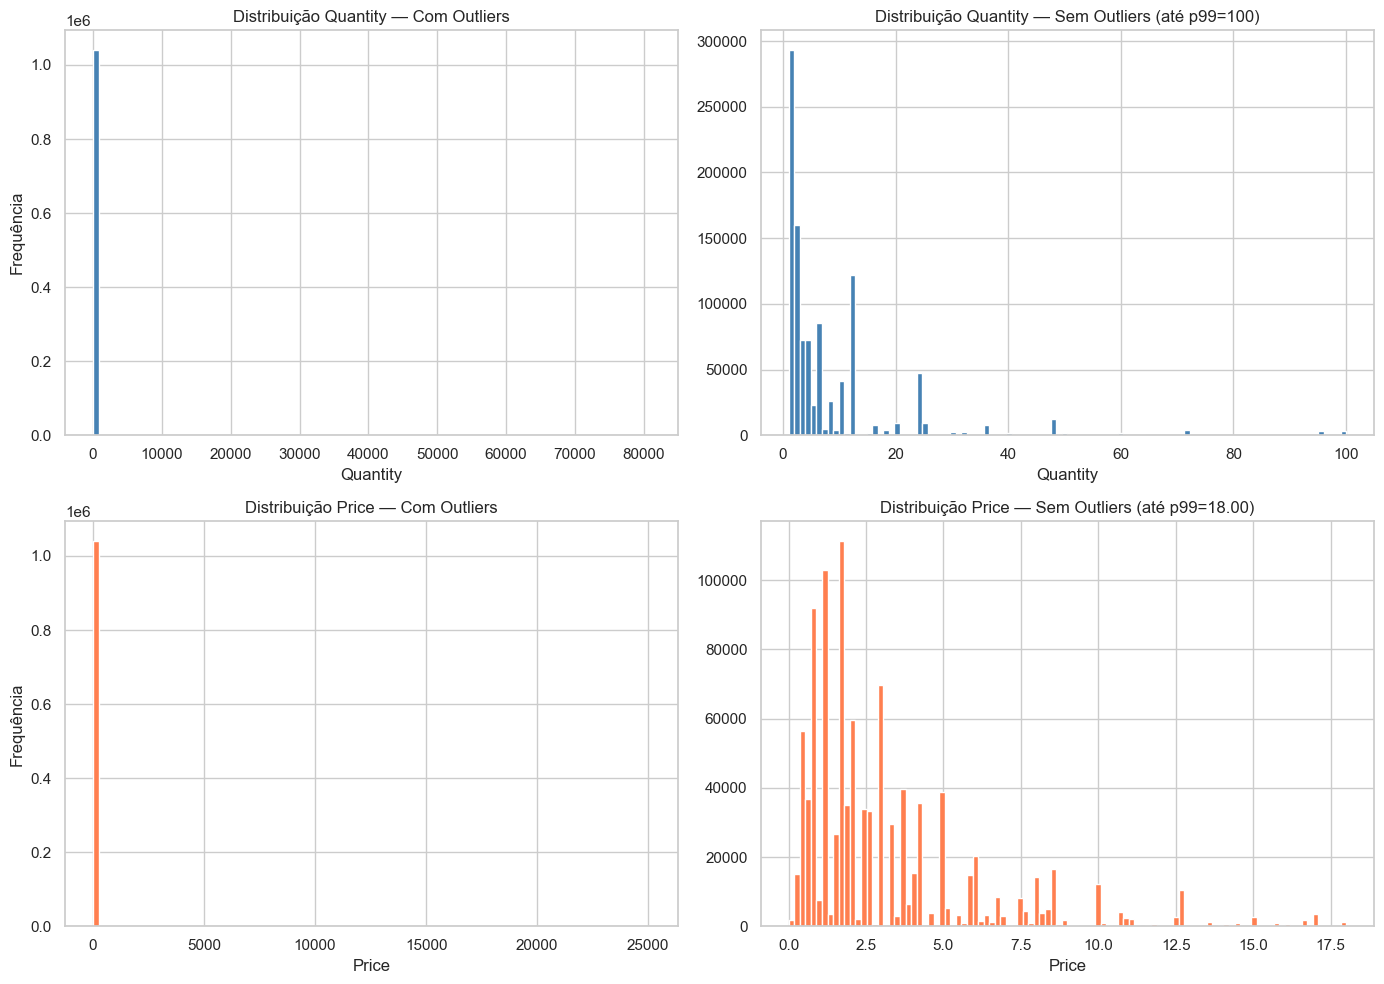

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Filtro de compras reais
df_limpo = df[
    (df['Quantity'] > 0) &
    (df['Price'] > 0) &
    (~df['Invoice'].astype(str).str.startswith('C'))
]

# Quantity — com outliers
axes[0,0].hist(df_limpo['Quantity'], bins=100, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribuição Quantity — Com Outliers')
axes[0,0].set_xlabel('Quantity')
axes[0,0].set_ylabel('Frequência')

# Quantity — sem outliers (percentil 99)
q99 = df_limpo['Quantity'].quantile(0.99)
axes[0,1].hist(df_limpo[df_limpo['Quantity'] <= q99]['Quantity'], 
               bins=100, color='steelblue', edgecolor='white')
axes[0,1].set_title(f'Distribuição Quantity — Sem Outliers (até p99={q99:.0f})')
axes[0,1].set_xlabel('Quantity')

# Price — com outliers
axes[1,0].hist(df_limpo['Price'], bins=100, color='coral', edgecolor='white')
axes[1,0].set_title('Distribuição Price — Com Outliers')
axes[1,0].set_xlabel('Price')
axes[1,0].set_ylabel('Frequência')

# Price — sem outliers (percentil 99)
p99 = df_limpo['Price'].quantile(0.99)
axes[1,1].hist(df_limpo[df_limpo['Price'] <= p99]['Price'],
               bins=100, color='coral', edgecolor='white')
axes[1,1].set_title(f'Distribuição Price — Sem Outliers (até p99={p99:.2f})')
axes[1,1].set_xlabel('Price')

plt.tight_layout()
plt.show()

```
Decisão para o ETL

Quantity  →  aplicar corte no percentil 99 (acima de 100 = outlier)
Price     →  aplicar corte no percentil 99 (acima de £18 = outlier)

Exceção: clientes B2B identificados (EIRE, top clientes)
         podem ter quantidades altas legítimas
         → tratar separadamente, não simplesmente remover


### Célula 22 — Sumário final do EDA

In [31]:
print("""
╔══════════════════════════════════════════════════════╗
║           SUMÁRIO FINAL DO EDA                       ║
╠══════════════════════════════════════════════════════╣
║  PROBLEMAS CRÍTICOS — TRATAR NO ETL                  ║
╠══════════════════════════════════════════════════════╣
║  1. Customer ID nulo        → 243.007 linhas (22,77%)║
║  2. Duplicatas verdadeiras  → 34.335 linhas  (3,22%) ║
║  3. Cancelamentos (C)       → 19.494 linhas  (1,83%) ║
║  4. Ajustes contábeis (A)   → 5 linhas               ║
║  5. StockCode não-produto   → 6.093 linhas           ║
║  6. Price zero              → 6.202 linhas           ║
║  7. Price negativo          → 5 linhas               ║
║  8. Outliers Quantity       → corte no p99 (>100)    ║
║  9. Customer ID como float  → converter para string  ║
╠══════════════════════════════════════════════════════╣
║  INSIGHTS DE NEGÓCIO                                 ║
╠══════════════════════════════════════════════════════╣
║  1. Negócio B2B confirmado                           ║
║  2. 91,9%% transações do Reino Unido                 ║
║  3. Sazonalidade clara — pico em Novembro            ║
║  4. Pareto: top 20%% clientes = 70,6%% da receita    ║
║  5. Janela de compra: Quinta, 10h-14h                ║
║  6. EIRE: 5 clientes VIP de altíssimo valor          ║
╠══════════════════════════════════════════════════════╣
║  PRÓXIMA ETAPA                                       ║
╠══════════════════════════════════════════════════════╣
║  02_preprocessing.ipynb — ETL baseado nesse sumário  ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║           SUMÁRIO FINAL DO EDA                       ║
╠══════════════════════════════════════════════════════╣
║  PROBLEMAS CRÍTICOS — TRATAR NO ETL                  ║
╠══════════════════════════════════════════════════════╣
║  1. Customer ID nulo        → 243.007 linhas (22,77%)║
║  2. Duplicatas verdadeiras  → 34.335 linhas  (3,22%) ║
║  3. Cancelamentos (C)       → 19.494 linhas  (1,83%) ║
║  4. Ajustes contábeis (A)   → 5 linhas               ║
║  5. StockCode não-produto   → 6.093 linhas           ║
║  6. Price zero              → 6.202 linhas           ║
║  7. Price negativo          → 5 linhas               ║
║  8. Outliers Quantity       → corte no p99 (>100)    ║
║  9. Customer ID como float  → converter para string  ║
╠══════════════════════════════════════════════════════╣
║  INSIGHTS DE NEGÓCIO                                 ║
╠══════════════════════════════════════════════════════╣
║  1. Negócio B2B confirmado  